In [1]:
# Install pygbif
!pip install pygbif

In [2]:
# Import the below libraries
import time
import zipfile
from getpass import getpass
from glob import glob

import pygbif.occurrences as occ
import pygbif.species as species
import requests

# Import the following libraries to work with reproducible file paths
import os
import pathlib

# Import the following libraries to work with tabular data
import pygbif.occurrences as occ
import geopandas as gpd
import pandas as pd
import pygbif.species as species

# Import the earthpy library to manage the data
import earthpy

import nest_asyncio
nest_asyncio.apply()

INFO:NumExpr defaulting to 16 threads.


In [3]:
# Establish the ability to create paths
from pathlib import Path

# Create the main project directory
miller_moth_dir = Path("miller-moth-dir")
miller_moth_dir.mkdir(parents=True, exist_ok=True)

In [4]:
reset_credentials = True

# Securely request and store GBIF username, password, and email address
if (not ('GBIF_USER'  in os.environ)) or reset:
    os.environ['GBIF_USER'] = input('GBIF username:')

if (not ('GBIF_PWD'  in os.environ)) or reset:
    os.environ['GBIF_PWD'] = getpass('GBIF password:')
    
if (not ('GBIF_EMAIL'  in os.environ)) or reset:
    os.environ['GBIF_EMAIL'] = input('GBIF email:')

In [5]:
# Conduct a search query for the miller moth
species_info = species.name_lookup('Euxoa auxiliaris', rank='SPECIES')

# Obtain the first result
first_result = species_info['results'][0]

# Find the species key
species_key = first_result['nubKey']

# Check the search query output
first_result['species'], species_key

('Euxoa auxiliaris', 4301148)

In [6]:
# Only download the data once
gbif_miller_pattern = os.path.join(miller_moth_dir, "gbif_data")
if not glob(gbif_miller_pattern):
    # Only submit one request
    if not 'GBIF_DOWNLOAD_KEY' in os.environ:
        # Submit query to GBIF
        gbif_query = occ.download([
            f'speciesKey = { species_key }',
            'hasCoordinate = True',
            f'year = 2023',
        ])
        # Take the first result
        os.environ['GBIF_DOWNLOAD_KEY'] = gbif_query[0]

    # Wait for the download to build
    dld_key = os.environ['GBIF_DOWNLOAD_KEY']
    wait = occ.download_meta(dld_key)['status']
    while not wait=='SUCCEEDED':
        wait = occ.download_meta(dld_key)['status']
        time.sleep(5)

    # Download the GBIF data
    dld_info = occ.download_get(
        os.environ['GBIF_DOWNLOAD_KEY'], 
        path=miller_moth_dir)
    dld_path = dld_info['path']

    # Unzip the GBIF data
    with zipfile.ZipFile(dld_path) as dld_zip:
        dld_zip.extractall(path=miller_moth_dir)
        
    # Clean up the GBIF .zip file
    os.remove(dld_path)

gbif_df = glob(gbif_miller_pattern)

INFO:Your download key is 0011026-251025141854904
INFO:Download file size: 30630 bytes
INFO:On disk at miller-moth-dir/0011026-251025141854904.zip


In [7]:
# Import csv to read csv files
import csv

# Establish the path to the GBIF data file
gbif_path = Path("miller-moth-dir/miller_moth_migration_data.csv")

# Load the GBIF data
gbif_df = pd.read_csv(
    gbif_path,
    delimiter='\t',
        index_col='gbifID',
        usecols=['gbifID', 'eventDate','decimalLatitude', 'decimalLongitude']
)
gbif_df.head()

,decimalLatitude,decimalLongitude,eventDate
gbifID,,,
5864861599,35.14000,-116.1049,2023-05-11
5864802218,35.14000,-116.1049,2023-05-11
5864602473,34.14900,-116.4560,2023-05-13
5864540779,32.63425,-116.0931,2023-04-11
5864524289,35.14000,-116.1049,2023-05-11


In [8]:
# Extract the month
gbif_df['eventDate'] = pd.to_datetime(gbif_df['eventDate'], errors='coerce')
gbif_df['month'] = gbif_df['eventDate'].dt.month

gbif_df.head()

,decimalLatitude,decimalLongitude,eventDate,month
gbifID,,,,
5864861599,35.14000,-116.1049,2023-05-11,5.0
5864802218,35.14000,-116.1049,2023-05-11,5.0
5864602473,34.14900,-116.4560,2023-05-13,5.0
5864540779,32.63425,-116.0931,2023-04-11,4.0
5864524289,35.14000,-116.1049,2023-05-11,5.0


In [11]:
# Import numpy as np
import numpy as np

In [12]:
# When downloading the data, give all variables descriptive names

# Set up the ecoregions URL
ecoregions_url = ("https://storage.googleapis.com/teow2016/Ecoregions2017.zip")
# Source: (Dinerstein et al., 2017)

# Create a path to save the ecoregions data
ecoregions_dir = os.path.join(miller_moth_dir, 'resolve_ecoregions')

# Create the ecoregions directory
os.makedirs(ecoregions_dir, exist_ok = True)

# Join the ecoregions shapefile path
ecoregions_path = os.path.join(ecoregions_dir, 'ecoregions.shp')

# Set up the conditional to only download the path once
if not os.path.exists(ecoregions_path):
    ecoregions_gdf = gpd.read_file(ecoregions_url)
    ecoregions_gdf.to_file(ecoregions_path)

<Axes: >

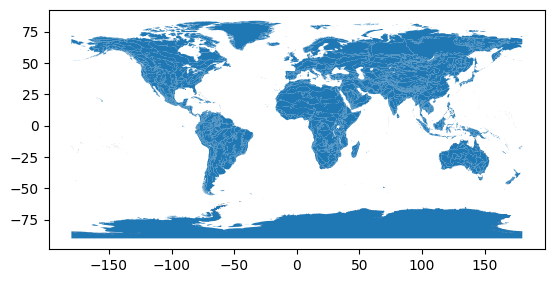

In [13]:
# Open up the ecoregions boundaries
ecoregions_gdf = gpd.read_file(ecoregions_path)
['OBJECT_ID', 'ECO_NAME', 'SHAPE_AREA', 'geometry']

# Plot the ecoregions quickly to check if the download was successful
ecoregions_gdf.plot()

In [14]:
from shapely.geometry import Point

# Convert the GBIF DataFrame to a GeoDataFrame
gbif_gdf = gpd.GeoDataFrame(
    gbif_df,
    geometry=gpd.points_from_xy(gbif_df['decimalLongitude'], gbif_df['decimalLatitude']),
    crs="EPSG:4326"  
)
    
# Reproject the ecoregions to match GBIF's CRS
ecoregions_gdf = ecoregions_gdf.to_crs(gbif_gdf.crs)

# Spatially join the observations to their ecoregions
gbif_ecoregions_gdf = gpd.sjoin(gbif_gdf, ecoregions_gdf, how="left", predicate="within")
    

gbif_ecoregions_gdf.head()

,decimalLatitude,decimalLongitude,eventDate,month,geometry,index_right,OBJECTID,ECO_NAME,BIOME_NUM,BIOME_NAME,...,ECO_BIOME_,NNH,ECO_ID,SHAPE_LENG,SHAPE_AREA,NNH_NAME,COLOR,COLOR_BIO,COLOR_NNH,LICENSE
gbifID,,,,,,,,,,,,,,,,,,,,,
5864861599,35.14000,-116.1049,2023-05-11,5.0,POINT (-116.1049 35.14),444.0,449.0,Mojave desert,13.0,Deserts & Xeric Shrublands,...,NE13,2.0,433.0,39.466467,12.682528,Nature Could Reach Half Protected,#FA5D4E,#CC6767,#7BC141,CC-BY 4.0
5864802218,35.14000,-116.1049,2023-05-11,5.0,POINT (-116.1049 35.14),444.0,449.0,Mojave desert,13.0,Deserts & Xeric Shrublands,...,NE13,2.0,433.0,39.466467,12.682528,Nature Could Reach Half Protected,#FA5D4E,#CC6767,#7BC141,CC-BY 4.0
5864602473,34.14900,-116.4560,2023-05-13,5.0,POINT (-116.456 34.149),444.0,449.0,Mojave desert,13.0,Deserts & Xeric Shrublands,...,NE13,2.0,433.0,39.466467,12.682528,Nature Could Reach Half Protected,#FA5D4E,#CC6767,#7BC141,CC-BY 4.0
5864540779,32.63425,-116.0931,2023-04-11,4.0,POINT (-116.0931 32.63425),639.0,644.0,Sonoran desert,13.0,Deserts & Xeric Shrublands,...,NE13,2.0,435.0,72.143632,21.416224,Nature Could Reach Half Protected,#FA5870,#CC6767,#7BC141,CC-BY 4.0
5864524289,35.14000,-116.1049,2023-05-11,5.0,POINT (-116.1049 35.14),444.0,449.0,Mojave desert,13.0,Deserts & Xeric Shrublands,...,NE13,2.0,433.0,39.466467,12.682528,Nature Could Reach Half Protected,#FA5D4E,#CC6767,#7BC141,CC-BY 4.0


In [15]:
# Extract the month
gbif_ecoregions_gdf['eventDate'] = pd.to_datetime(gbif_ecoregions_gdf['eventDate'], errors='coerce')
gbif_ecoregions_gdf['month'] = gbif_ecoregions_gdf['eventDate'].dt.month

gbif_ecoregions_gdf.head()

,decimalLatitude,decimalLongitude,eventDate,month,geometry,index_right,OBJECTID,ECO_NAME,BIOME_NUM,BIOME_NAME,...,ECO_BIOME_,NNH,ECO_ID,SHAPE_LENG,SHAPE_AREA,NNH_NAME,COLOR,COLOR_BIO,COLOR_NNH,LICENSE
gbifID,,,,,,,,,,,,,,,,,,,,,
5864861599,35.14000,-116.1049,2023-05-11,5.0,POINT (-116.1049 35.14),444.0,449.0,Mojave desert,13.0,Deserts & Xeric Shrublands,...,NE13,2.0,433.0,39.466467,12.682528,Nature Could Reach Half Protected,#FA5D4E,#CC6767,#7BC141,CC-BY 4.0
5864802218,35.14000,-116.1049,2023-05-11,5.0,POINT (-116.1049 35.14),444.0,449.0,Mojave desert,13.0,Deserts & Xeric Shrublands,...,NE13,2.0,433.0,39.466467,12.682528,Nature Could Reach Half Protected,#FA5D4E,#CC6767,#7BC141,CC-BY 4.0
5864602473,34.14900,-116.4560,2023-05-13,5.0,POINT (-116.456 34.149),444.0,449.0,Mojave desert,13.0,Deserts & Xeric Shrublands,...,NE13,2.0,433.0,39.466467,12.682528,Nature Could Reach Half Protected,#FA5D4E,#CC6767,#7BC141,CC-BY 4.0
5864540779,32.63425,-116.0931,2023-04-11,4.0,POINT (-116.0931 32.63425),639.0,644.0,Sonoran desert,13.0,Deserts & Xeric Shrublands,...,NE13,2.0,435.0,72.143632,21.416224,Nature Could Reach Half Protected,#FA5870,#CC6767,#7BC141,CC-BY 4.0
5864524289,35.14000,-116.1049,2023-05-11,5.0,POINT (-116.1049 35.14),444.0,449.0,Mojave desert,13.0,Deserts & Xeric Shrublands,...,NE13,2.0,433.0,39.466467,12.682528,Nature Could Reach Half Protected,#FA5D4E,#CC6767,#7BC141,CC-BY 4.0


In [16]:
miller_gbif_ecoregions_gdf = (
    # Define the required columns
    # Keeping geometry maintains the GeoDataFrame
    gbif_ecoregions_gdf[['OBJECTID', 'month', 'geometry']] 
    # Rename "OBJECTID" to "ecoregion"
    .rename(columns={'OBJECTID': 'ecoregion'})              
)

miller_gbif_ecoregions_gdf.head()

,ecoregion,month,geometry
gbifID,,,
5864861599,449.0,5.0,POINT (-116.1049 35.14)
5864802218,449.0,5.0,POINT (-116.1049 35.14)
5864602473,449.0,5.0,POINT (-116.456 34.149)
5864540779,644.0,4.0,POINT (-116.0931 32.63425)
5864524289,449.0,5.0,POINT (-116.1049 35.14)


In [17]:
# Count all observations in each month
occurrence_df = (
    miller_gbif_ecoregions_gdf
    # Specify the required columns
     [['ecoregion', 'month']]
    # Group by each ecoregion and month
    .groupby(['ecoregion', 'month'])
    # Count the number of occurrences
    .agg(occurrences=('ecoregion', 'count'))
)
occurrence_df

# Exclude rare observations (possible misidentifications)
occurrence_df = occurrence_df[occurrence_df.occurrences > 1]

# Take the mean by ecoregion
mean_occurrences_by_ecoregion = (
    occurrence_df.groupby('ecoregion').mean()
)

# Take the mean by month
mean_occurrences_by_month = (
    occurrence_df.groupby('month').mean()
)

In [18]:
# Normalize by space and time for sampling effort
occurrence_df['norm_occurrences'] = (
    occurrence_df
    # Divide by mean occurrences by ecoregion and month
    / mean_occurrences_by_ecoregion
    / mean_occurrences_by_month
)
occurrence_df

occurrences  norm_occurrences
ecoregion month                               
92.0      5.0              2          0.069767
449.0     4.0              7          0.051282
          5.0             35          0.116279
518.0     5.0              6          0.104651
          6.0              4          0.250000
          8.0              2          0.250000
644.0     4.0              6          0.153846

<Axes: xlabel='month', ylabel='norm_occurrences'>

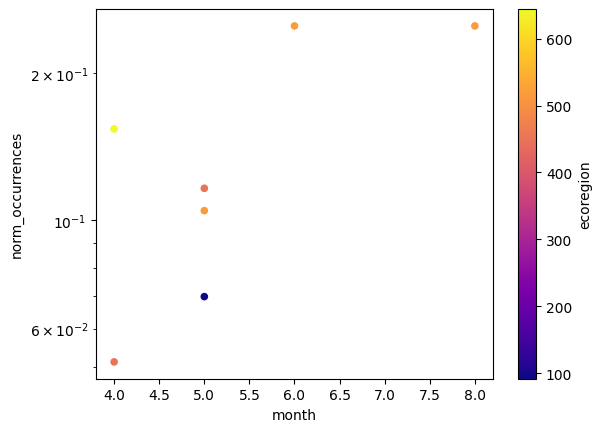

In [19]:
# Plot the normalized occurrences
occurrence_df.reset_index().plot.scatter(
    x='month',
    y='norm_occurrences',
    c='ecoregion',
    cmap='plasma',          
    logy=True               
)

In [20]:
# Import calendar to get month names
import calendar

# Import the below libraries for dynamic mapping
import cartopy.crs as ccrs
import panel as pn
import hvplot.pandas
import holoviews as hv

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
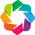

In [21]:
# Initialize the appropriate extensions
hv.extension('bokeh')  
pn.extension()  

In [22]:
# Simplify the ecoregions' geometry to speed up processing
ecoregions_gdf['geometry'] = ecoregions_gdf.simplify(.05, preserve_topology=False)

# Change the CRS to Mercator for mapping
ecoregions_gdf = ecoregions_gdf.to_crs(ccrs.Mercator())

# Check that the plot runs properly
ecoregions_gdf.hvplot()

:Polygons   [x,y]

In [23]:
# The indexes must match to join occurrences with the plotting GeoDataFrame

#  Rename ecoregions_gdf's "OBJECTID" to "ecoregion" to match occurrence_df
ecoregions_gdf = ecoregions_gdf.rename(columns = {'OBJECTID': 'ecoregion'})

# Set the index to "ecoregion"
ecoregions_gdf.set_index('ecoregion', inplace=True)

# Join the occurrences with the plotting GeoDataFrame
occurrence_gdf = ecoregions_gdf.join(occurrence_df)

In [ ]:
# Reset "occurrence_gdf" to a GeoDataFrame
occurrence_gdf = occurrence_gdf()

# Define the parameters of the slider widget
month_widget = pn.widgets.DiscreteSlider(
    name='Month',
    # Give the month names
    options={calendar.month_abbr[m]: m for m in range(1, 13)},
    value=1
)

# Obtain the plot bounds so they do not change with the slider
xmin, ymin, xmax, ymax = occurrence_gdf.total_bounds

# Plot occurrence by ecoregion and month
# Group by month
migration_plot = (
    occurrence_gdf
    .hvplot(
        groupby='month',
        # Use background tiles
        geo=True,
        crs='EPSG:3857',
        color='norm_occurrences',
        cmap='plasma',
        tiles='CartoLight',
        title="Miller Moth Migration",
        xlim=(xmin, xmax), ylim=(ymin, ymax),
        frame_height=600,
        frame_width=400,
        # Set the widget to be defined by month as a slider
        # Relocate the widget to the bottom
        widget_location='bottom',
        widgets = {'month': month_widget}
    )
)

# Show the plot
migration_plot

BokehModel(combine_events=True, render_bundle={'docs_json': {'54187f30-b91a-4383-a08e-7b5be05a636e': {'version…

In [39]:
# Save the plot
migration_plot.save('miller_moth_migration.html', embed=True)